In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import ceil

In [2]:
def read_no_ef(filename):
    data = []
    for idx in range(0, 50):
        file = f"output/temporal-interference/ltp/{idx}/no_ti/0/{filename}.csv"
        data.append(pd.read_csv(file, index_col = 0))
    
    return data

def read_ef(filename, carrier, phi, psi, offset):
    data = []
    for idx in range(0, 50):
        file = f"output/temporal-interference/ltp/{idx}/{carrier}/{phi}_{psi}_{offset}/{filename}.csv"
        data.append(pd.read_csv(file, index_col = 0))
    
    return data

In [3]:
def plot_spike_freq(
        carrier,
        phi = None,
        psi = None,
        offset = None,
        color = "black",
        axs = None
):
    if carrier == 0:
        spike_frequency = read_no_ef("spike_frequency")
    else:
        spike_frequency = read_ef("spike_frequency", carrier = carrier, phi = phi, psi = psi, offset = offset)

    if axs is None:
        ncols = 5
        nrows = ceil(len(spike_frequency) / ncols)
        _, axs = plt.subplots(nrows = nrows, ncols = ncols, figsize = (12, nrows * 2), sharex = True, sharey = True)

    for spikes, ax in zip(spike_frequency, axs.flatten()):
        ax.scatter(
            spikes.Time,
            spikes.Frequency,
            s = 5,
            color = color
        )
        ax.set_xlim(0, 2000)
        ax.set_ylim(0, 55)

    for row in range(axs.shape[0]):
        axs[row][0].set_ylabel("Frequency, Hz")

    for col in range(axs.shape[1]):
        last_row = axs.shape[0] - 1
        axs[last_row][col].set_xlabel("Time, ms")

In [4]:
def plot_synaptic_weight_change(
        carrier,
        phi = None,
        psi = None,
        offset = None
):
    if carrier == 0:
        synaptic_weights = read_no_ef("synapse_weights")
    else:
        synaptic_weights = read_ef("synapse_weights", carrier = carrier, phi = phi, psi = psi, offset = offset)

    ncols = 5
    nrows = ceil(len(synaptic_weights) / ncols)

    fig, axs = plt.subplots(nrows = nrows, ncols = ncols, figsize = (12, nrows * 2), sharex = True, sharey = True)

    for weights, ax in zip(synaptic_weights, axs.flatten()):
        for i in range(0, 10):
            ax.plot(
                weights.Time,
                weights[f"Synapse{i}"],
                linewidth = 0.5,
                color = "black"
            )

    for row in range(axs.shape[0]):
        axs[row][0].set_ylabel("Weight")

    for col in range(axs.shape[1]):
        last_row = axs.shape[0] - 1
        axs[last_row][col].set_xlabel("Time, ms")

    fig.tight_layout()

In [5]:
def plot_weight_distribution(
        carrier,
        phi = None,
        psi = None,
        offset = None,
        ax = None,
        color = "tab:blue",
        label = "Weights",
        show_legend = False,
        alpha = 1
):
    if carrier == 0:
        synapses = read_no_ef("synapse_info")
    else:
        synapses = read_ef("synapse_info", carrier = carrier, phi = phi, psi = psi, offset = offset)

    weights = []
    for synapse_info in synapses:
        weights.append(synapse_info.InitialWeight.values)
    
    weights = np.concatenate(weights)

    if ax is None:
        plt.hist(weights, bins = 25, color = color, label = label, alpha = alpha, histtype = "step")
        plt.xlim(-0.1, 1.1)
        plt.xlabel("Weight")
        plt.ylabel("Count")
        plt.title("Weight distribution")
        
        if show_legend:
            plt.legend()
    else:
        ax.hist(weights, bins = 25, color = color, label = label, alpha = alpha, histtype = "step")
        ax.set_xlim(-0.1, 1.1)
        ax.set_xlabel("Weight")
        ax.set_ylabel("Count")
        
        if carrier != 0:
            ax.set_title(fr"$f_{{\text{{carrier}}}}$ = {carrier} Hz, $\Delta f$ = {offset} Hz")
        else:
            ax.set_title("No EF")
        
        if show_legend:
            ax.legend()

# Running LTP protocol with and without electric field

The neuron has 10 synapses. Each synapse receives LTP inducing stimuli: 100 Hz stimulation for 1000 ms, starting at 500 ms and ending at 1500 ms of the simulation.

## No electric field

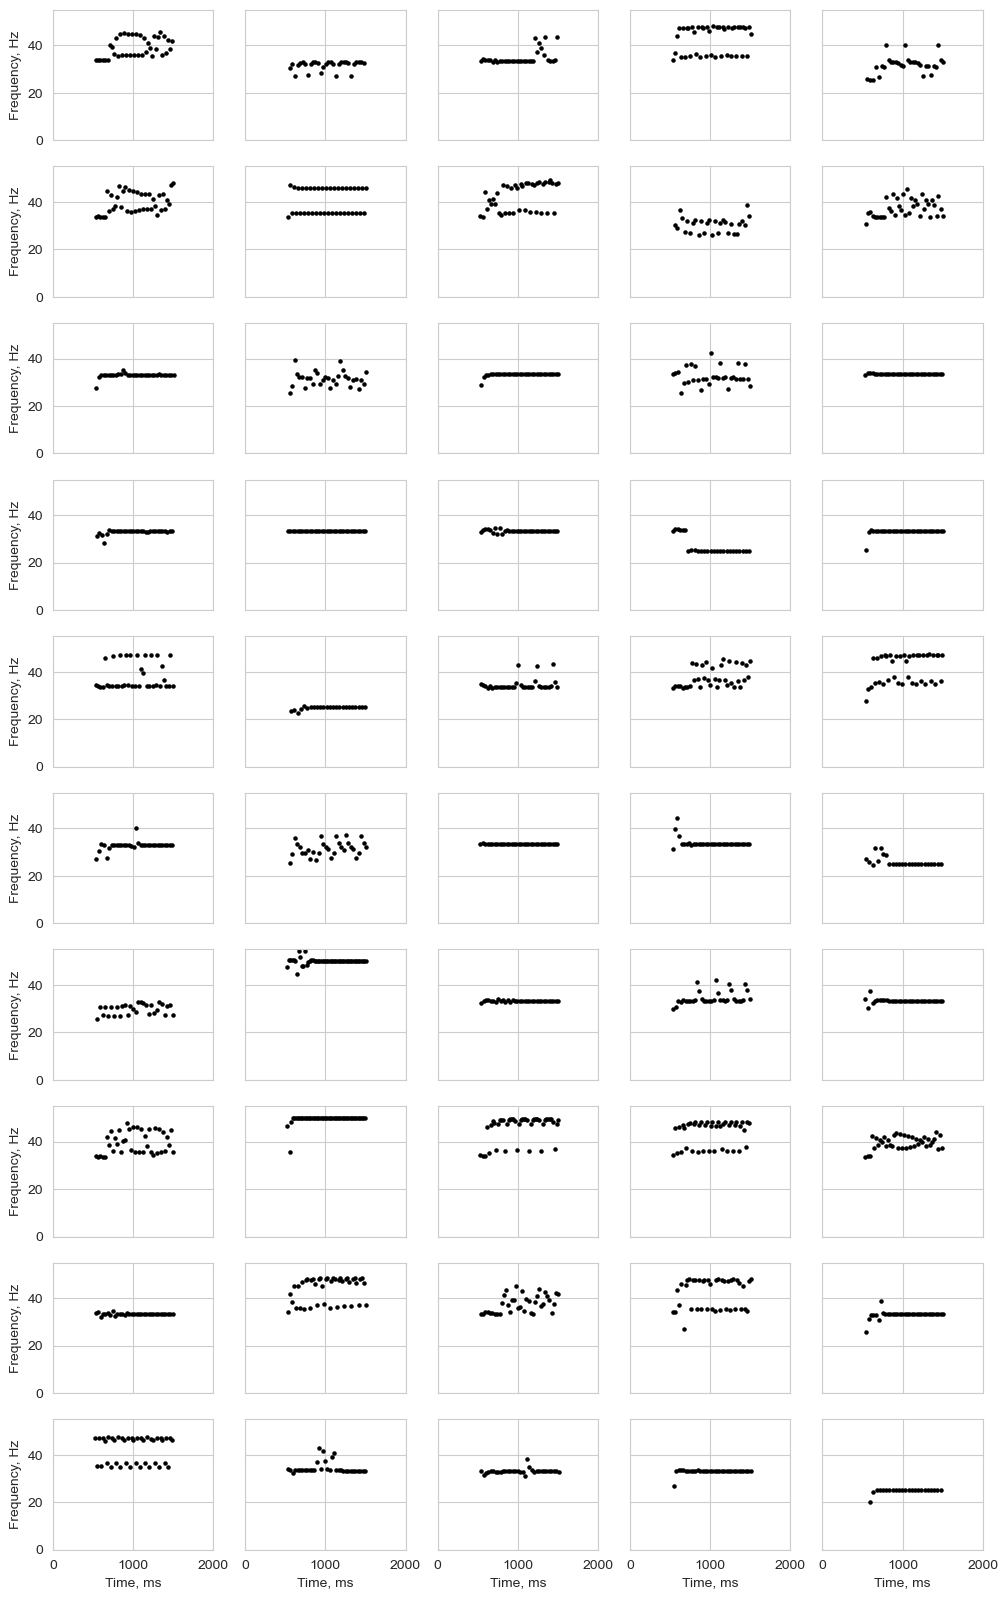

In [6]:
plot_spike_freq(carrier = 0)

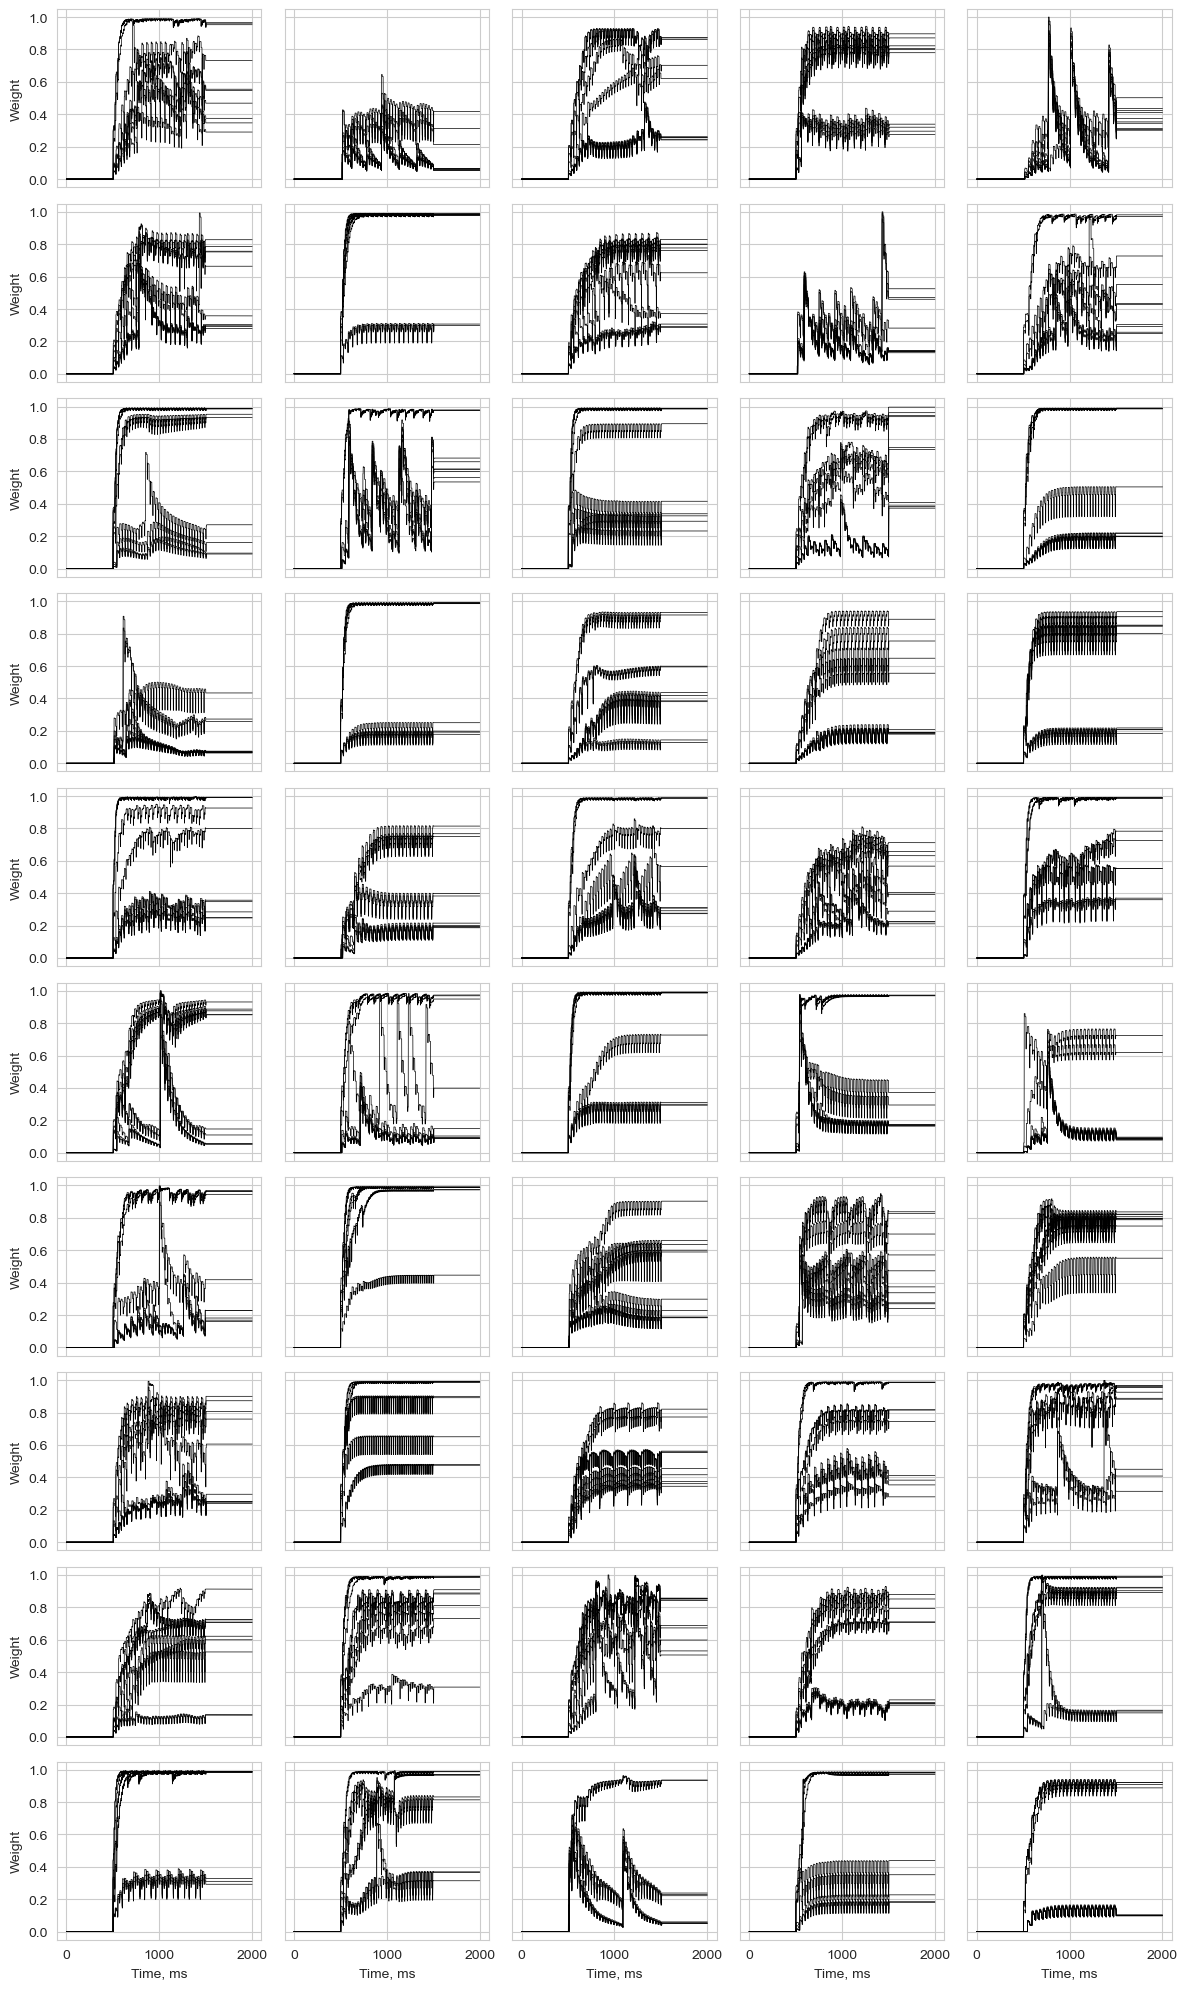

In [7]:
plot_synaptic_weight_change(carrier = 0)

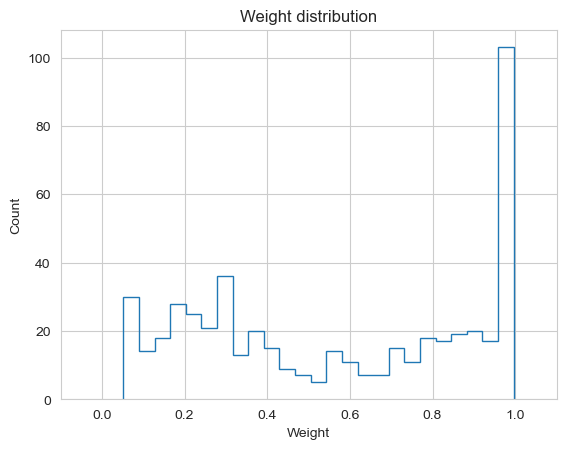

In [8]:
plot_weight_distribution(carrier = 0)

## 5 Hz TI EF (1k carrier)

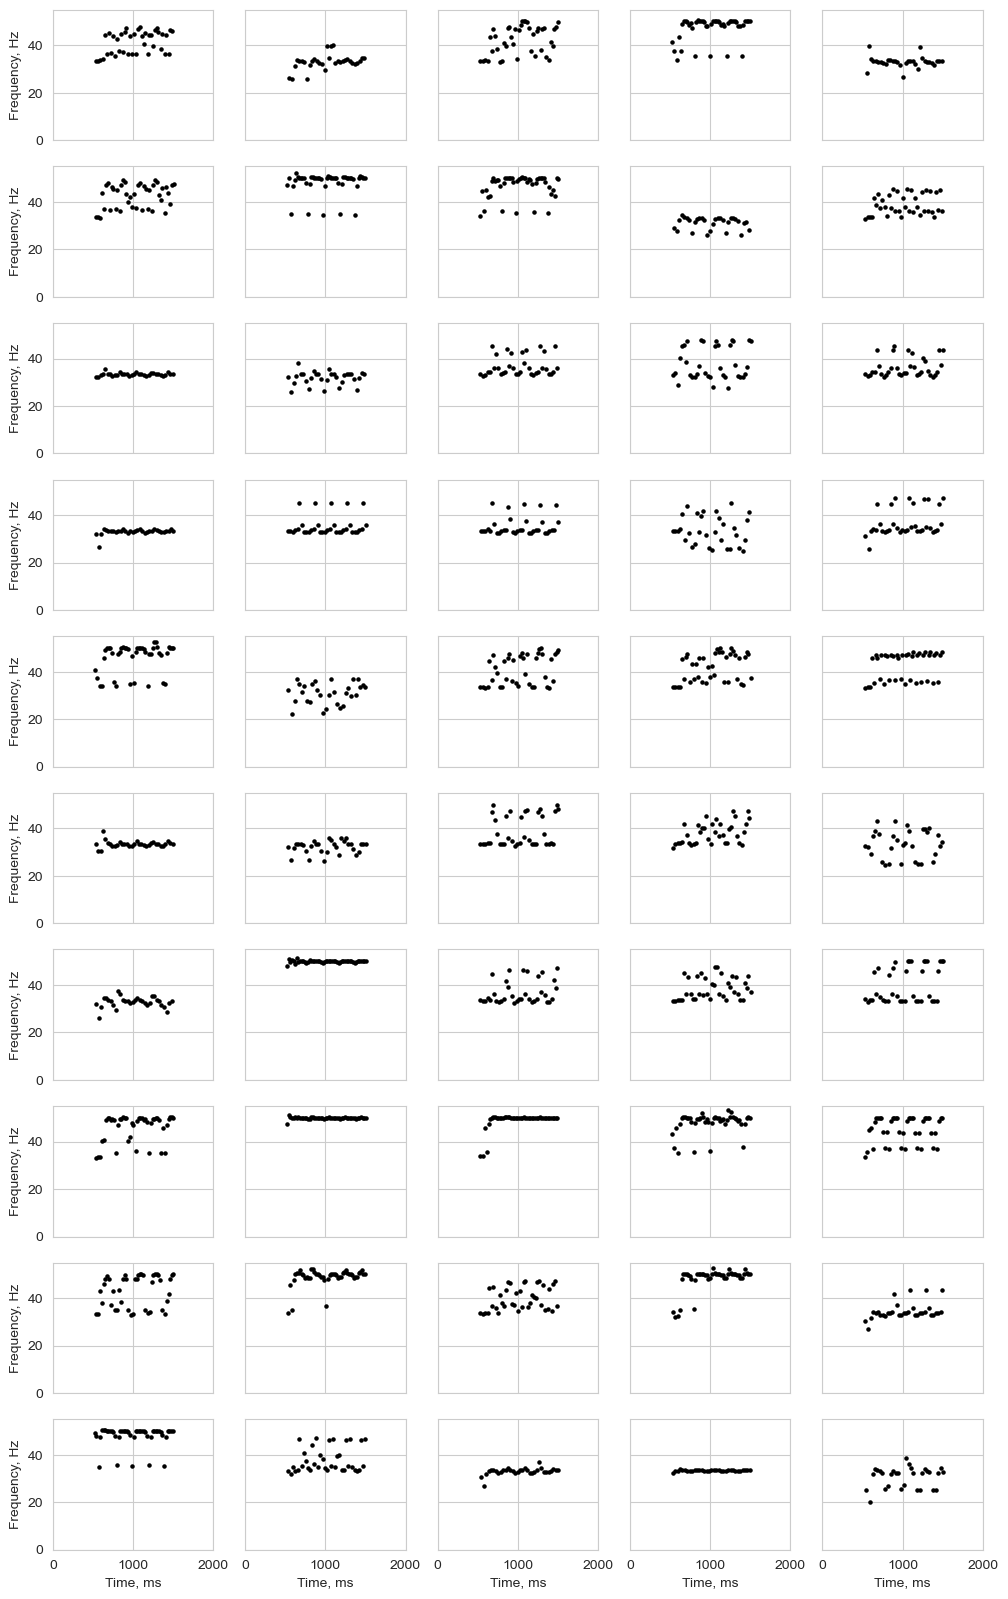

In [9]:
plot_spike_freq(
    carrier = 1000,
    phi = 90, psi = 90,
    offset = 5
)

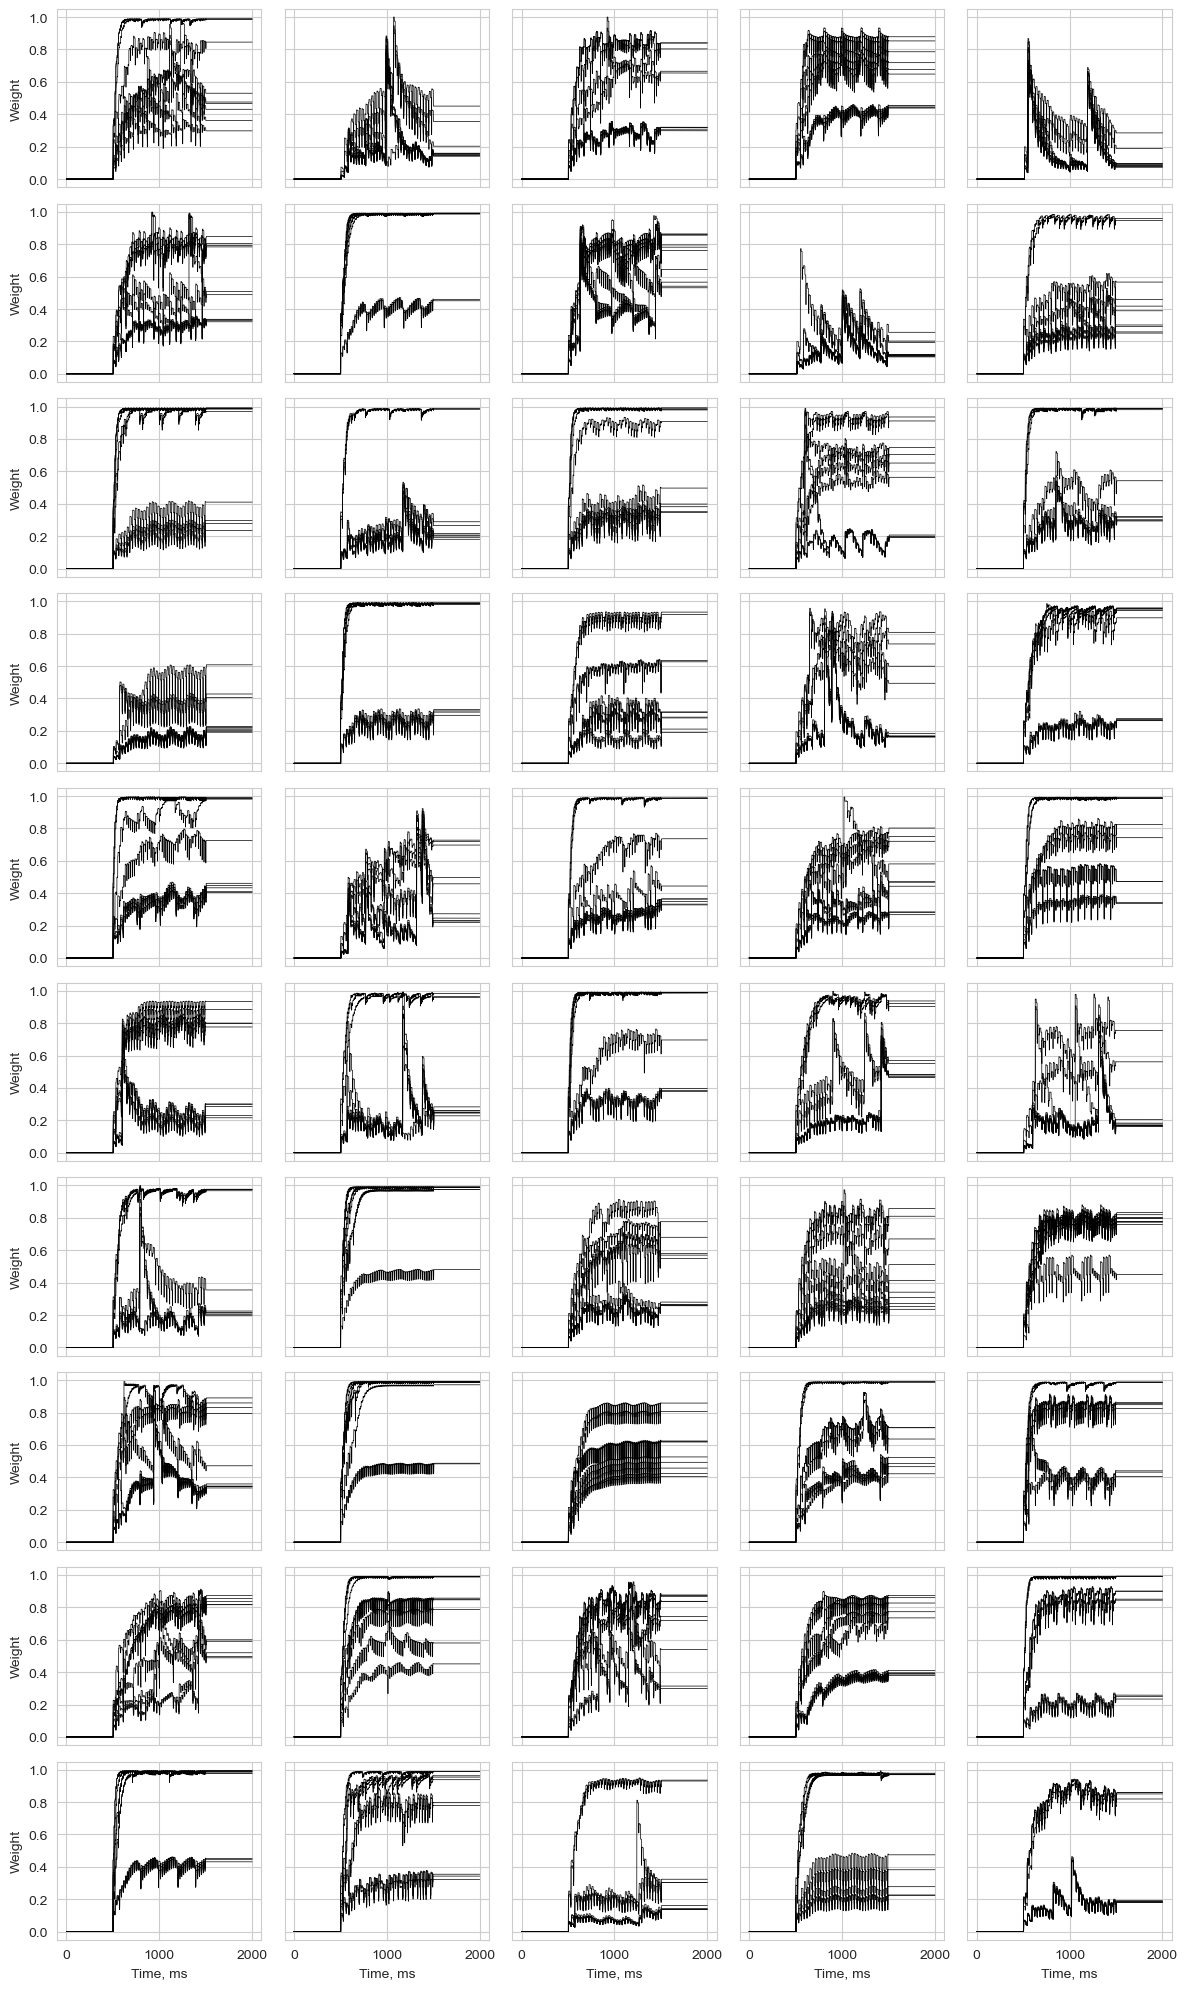

In [10]:
plot_synaptic_weight_change(
    carrier = 1000,
    phi = 90, psi = 90,
    offset = 5
)

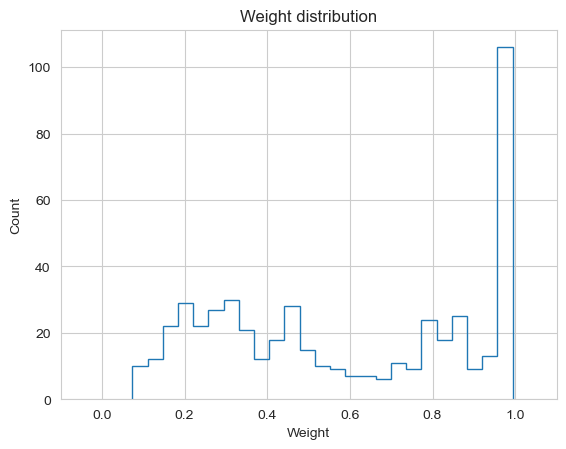

In [11]:
plot_weight_distribution(
    carrier = 1000,
    phi = 90, psi = 90,
    offset = 5
)

## 130 Hz TI EF (1k carrier)

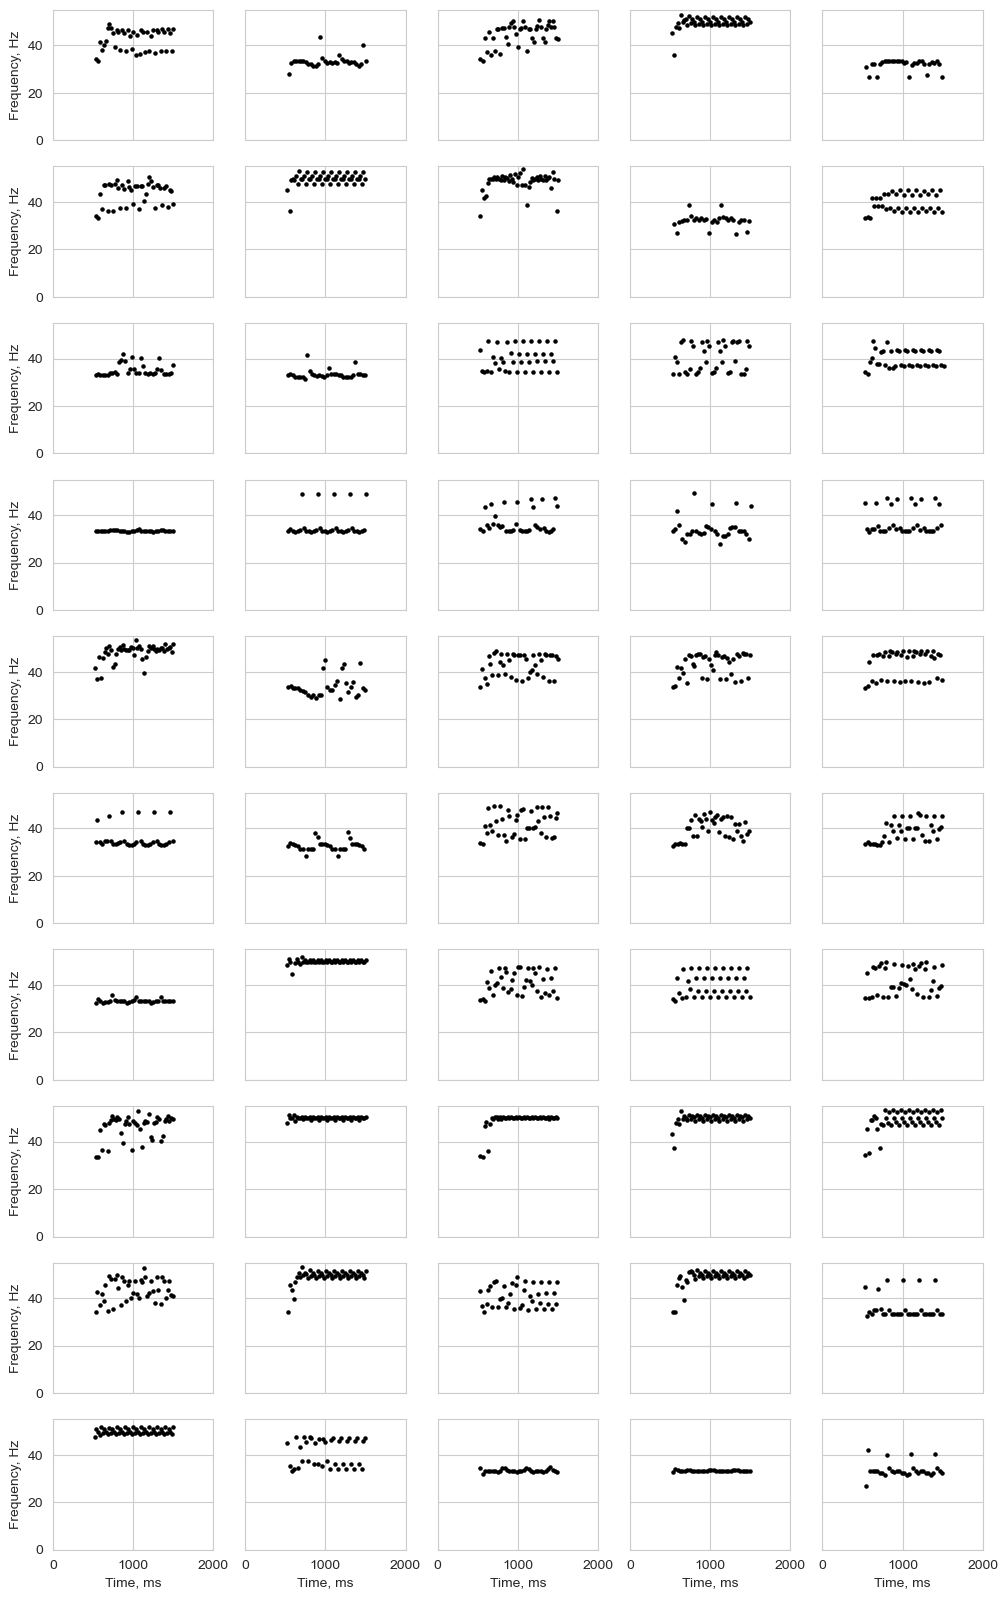

In [12]:
plot_spike_freq(
    carrier = 1000,
    phi = 90, psi = 90,
    offset = 130
)

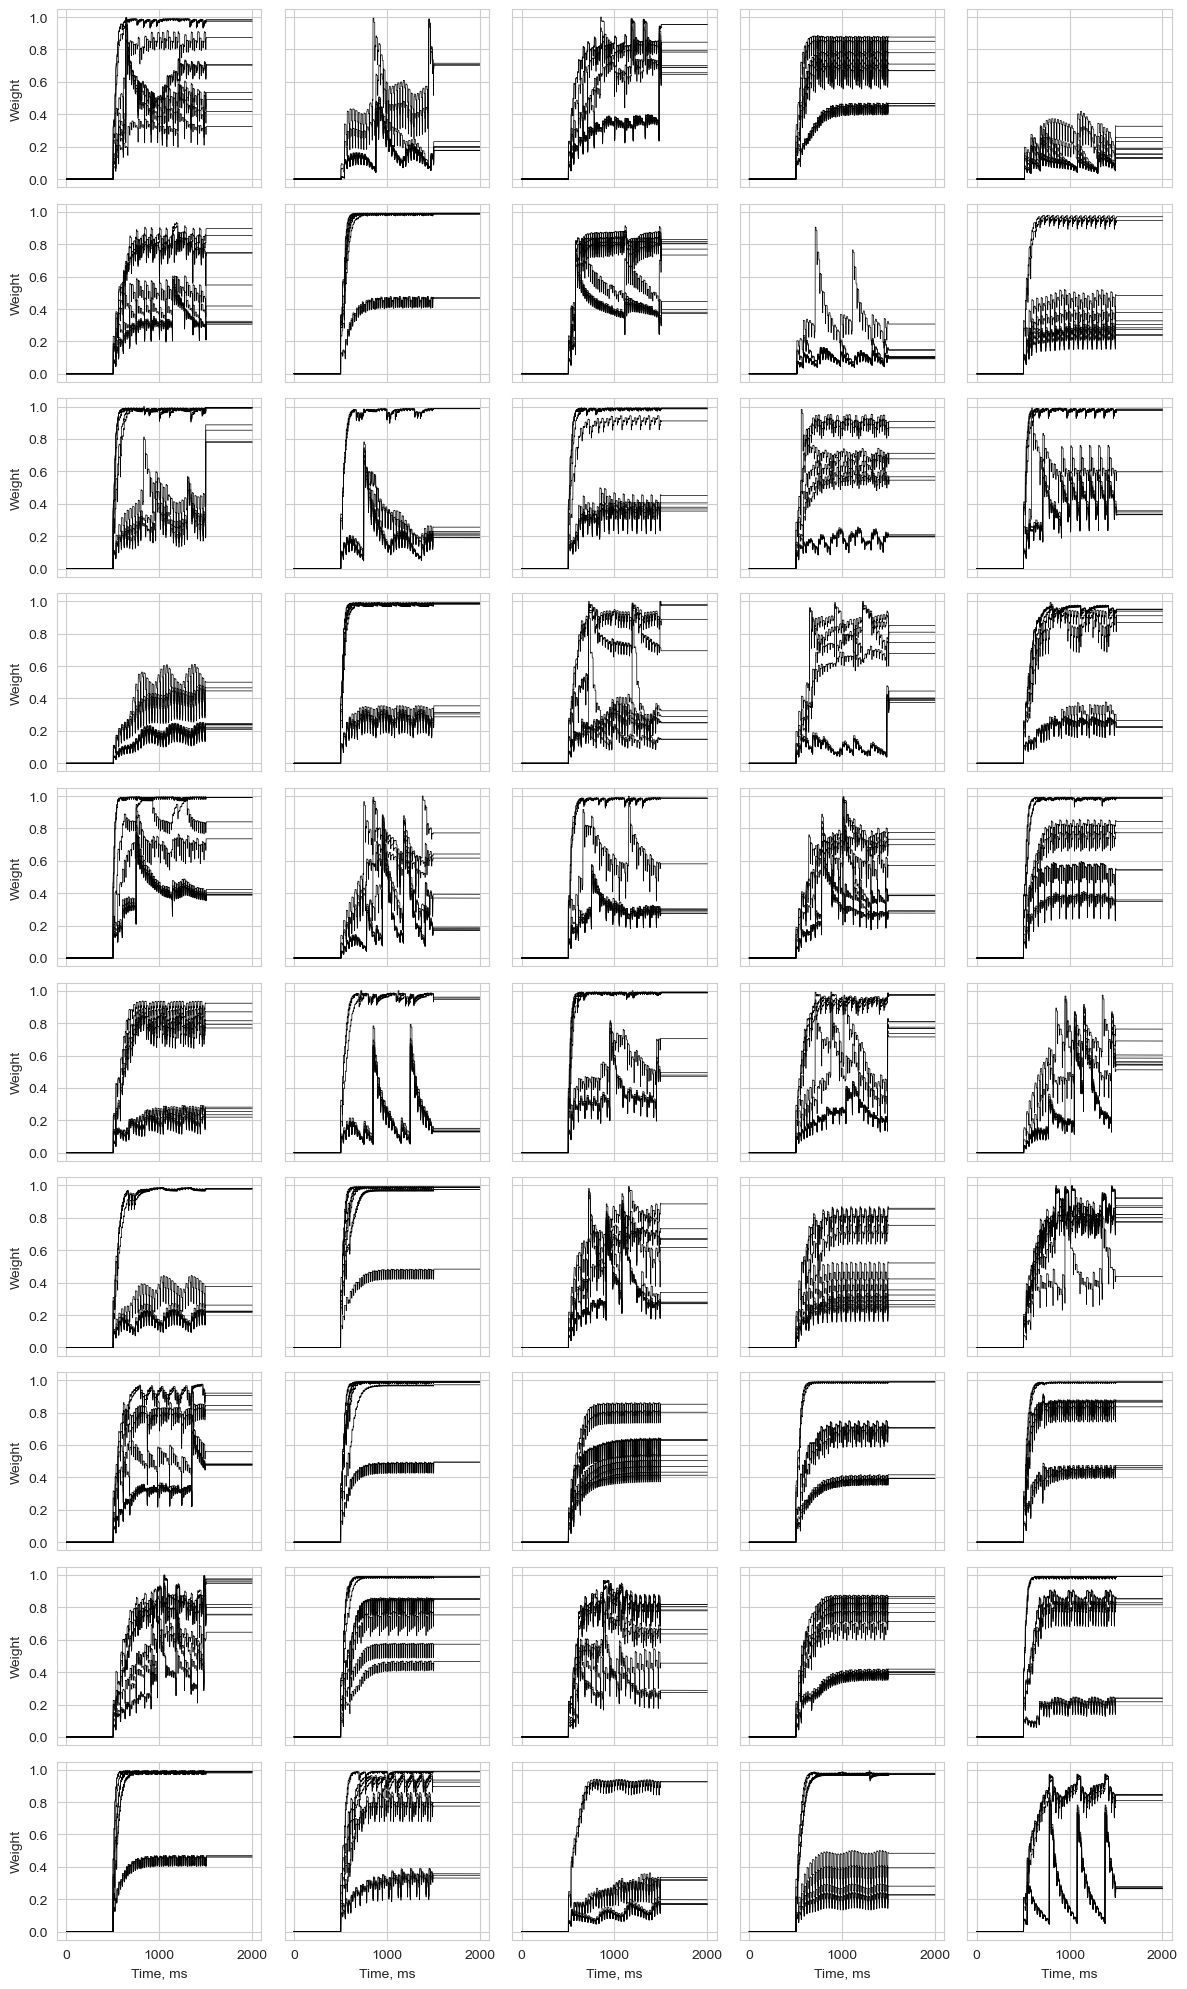

In [13]:
plot_synaptic_weight_change(
    carrier = 1000,
    phi = 90, psi = 90,
    offset = 130
)

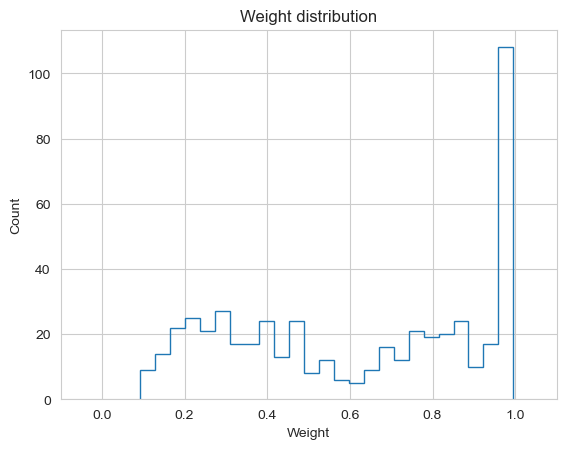

In [14]:
plot_weight_distribution(
    carrier = 1000,
    phi = 90, psi = 90,
    offset = 130
)

# Comparing no EF, 5 Hz TI EF and 130 Hz TI EF

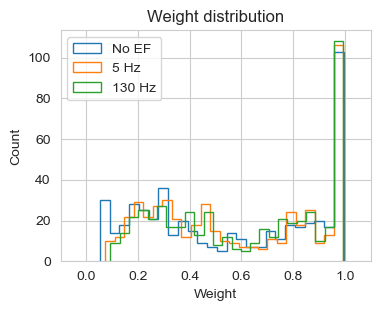

In [15]:
_, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 3))

plot_weight_distribution(
    carrier = 0,
    ax = axs,
    color = "tab:blue",
    label = "No EF"
)

plot_weight_distribution(
    carrier = 1000,
    phi = 90, psi = 90,
    offset = 5,
    ax = axs,
    color = "tab:orange",
    label = "5 Hz"
)

plot_weight_distribution(
    carrier = 1000,
    phi = 90, psi = 90,
    offset = 130,
    ax = axs,
    color = "tab:green",
    show_legend = True,
    label = "130 Hz"
)

axs.set_title("Weight distribution")
plt.show()

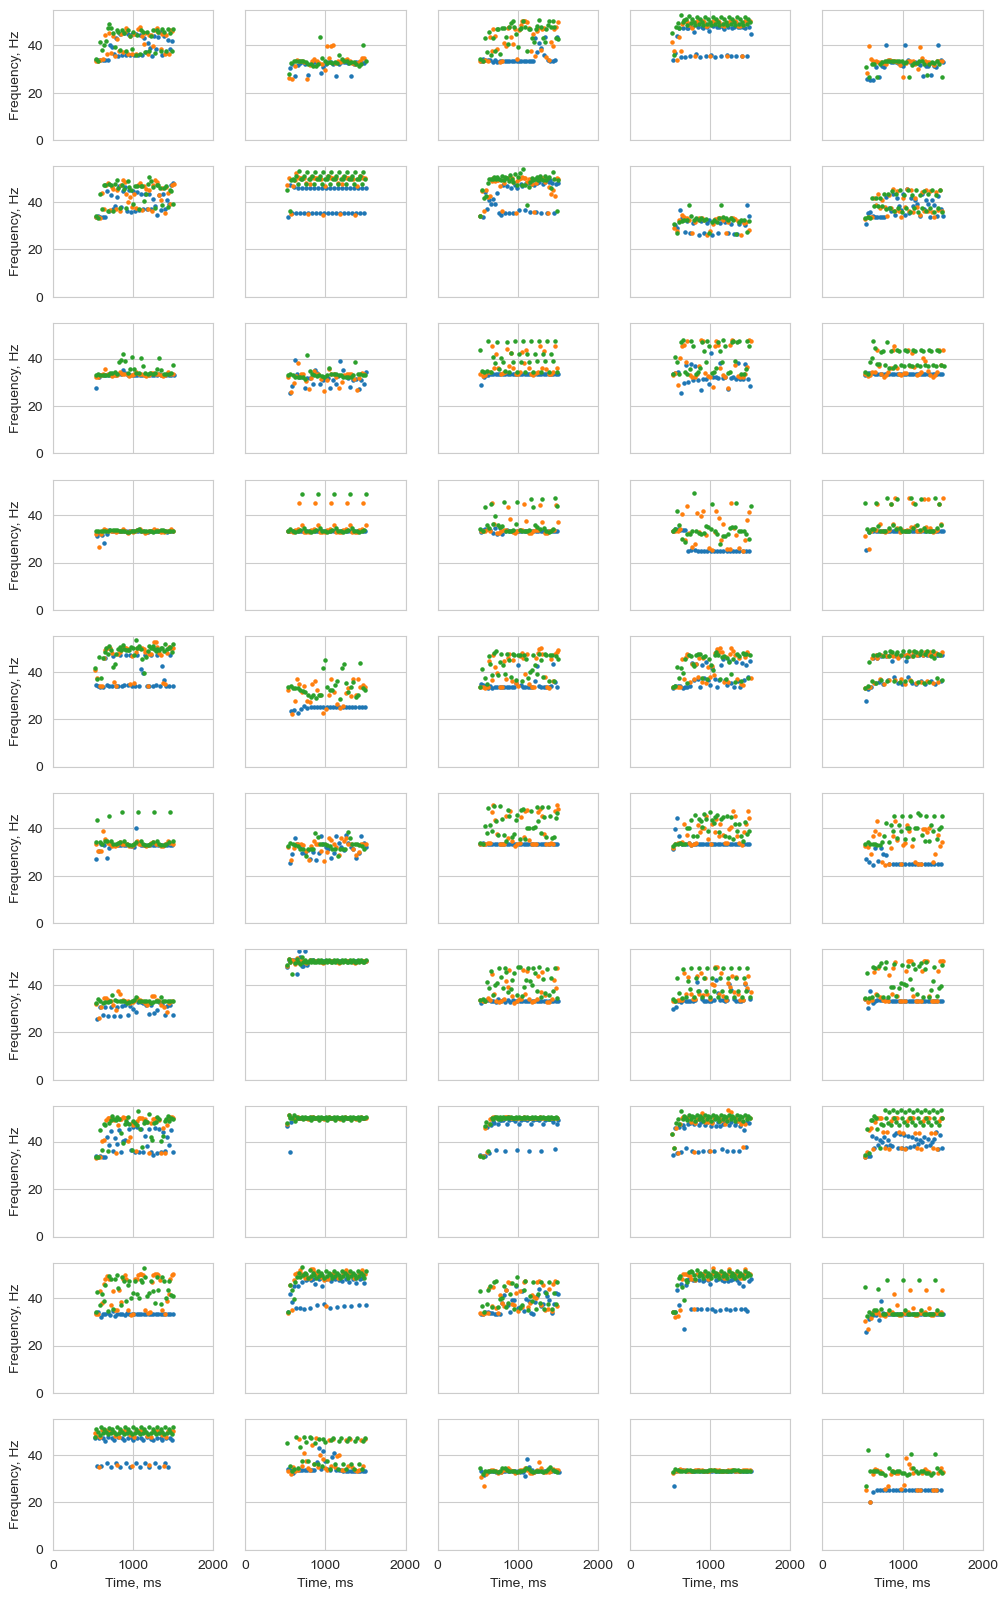

In [16]:
fig, axs = plt.subplots(nrows = 10, ncols = 5, figsize = (12, 10 * 2), sharex = True, sharey = True)

plot_spike_freq(
    carrier = 0,
    axs = axs,
    color = "tab:blue"
)

plot_spike_freq(
    carrier = 1000,
    phi = 90, psi = 90,
    offset = 5,
    axs = axs,
    color = "tab:orange"
)

plot_spike_freq(
    carrier = 1000,
    phi = 90, psi = 90,
    offset = 130,
    axs = axs,
    color = "tab:green"
)